In [1]:
import os
import sys
from pathlib import Path

# Change to project root (parent of notebooks/)
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
os.chdir(project_root)
sys.path.insert(0, str(project_root))  # For imports from pokeml/


print(f'PYTHONPATH added: {project_root}') # Verify: /path/to/project_root

# Load the minimal_pkdx
import pandas as pd
import numpy as np
df = pd.read_csv('datasets/pkdx_min.csv')

PYTHONPATH added: /Users/pano/Library/Mobile Documents/com~apple~CloudDocs/coding/portfolio/ml_pokemon


In [2]:
mask_reg = df['rarity'].eq('regular')
mask_leg = df['rarity'].eq('legendary')
stage_medians_reg = df.loc[mask_reg].groupby('stage')['total_stats'].median()
stage_medians_leg = df.loc[mask_leg].groupby('stage')['total_stats'].median()

eda = df.copy()
eda['median_stage'] = np.nan
eda.loc[mask_reg, 'median_stage'] = eda.loc[mask_reg, 'stage'].map(stage_medians_reg)
eda.loc[mask_leg, 'median_stage'] = eda.loc[mask_leg, 'stage'].map(stage_medians_leg)

eda['residual'] = eda['total_stats'] - eda['median_stage']
eda

,generation,name,type_1,type_2,rarity,stage,shape,color,total_stats,height,weight,median_stage,residual
0,1,bulbasaur,grass,poison,regular,s1c3,quadruped,green,318,0.7,6.9,300.0,18.0
1,1,ivysaur,grass,poison,regular,s2c3,quadruped,green,405,1.0,13.0,405.0,0.0
2,1,venusaur,grass,poison,regular,s3c3,quadruped,green,525,2.0,100.0,521.5,3.5
3,1,charmander,fire,NaN,regular,s1c3,upright,red,309,0.6,8.5,300.0,9.0
4,1,charmeleon,fire,NaN,regular,s2c3,upright,red,405,1.1,19.0,405.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077,9,decidueye_hisui,grass,fighting,regular,s3c3,wings,brown,530,1.6,37.0,521.5,8.5
1078,9,dialga_hisui,steel,dragon,legendary,single,quadruped,white,680,7.0,848.7,590.0,90.0
1079,9,palkia_hisui,water,dragon,legendary,single,upright,purple,680,6.3,659.0,590.0,90.0
1080,9,wooper_paldea,poison,ground,regular,s1c2,legs,blue,210,0.4,11.0,310.0,-100.0


In [3]:
summary = (
    eda[eda['rarity'].eq('regular')]
    .groupby(['stage', 'type_1'])['residual']
    .agg(median='median', count='count')
    .reset_index()
)

mask_summary = summary[summary['count'] >=5]
mask_summary.head(40)

,stage,type_1,median,count
0,s1c2,bug,-32.5,22
1,s1c2,dark,20.0,14
2,s1c2,electric,-21.0,9
3,s1c2,fairy,2.0,5
4,s1c2,fighting,14.0,10
5,s1c2,fire,5.0,11
7,s1c2,ghost,-1.0,11
8,s1c2,grass,-15.0,19
9,s1c2,ground,7.5,14
10,s1c2,ice,-6.0,9


In [4]:
dual_t1 = eda[eda['type_2'].notna()][['stage', 'rarity', 'type_1', 'residual']]
dual_t2 = eda[eda['type_2'].notna()][['stage', 'rarity', 'type_2', 'residual']]

dual_t1 = dual_t1.rename(columns={'type_1': 'type'}).assign(order='dual_t1')
dual_t2 = dual_t2.rename(columns={'type_2': 'type'}).assign(order='dual_t2')

duals = pd.concat([dual_t1, dual_t2], ignore_index=True)

duals

,stage,rarity,type,residual,order
0,s1c3,regular,grass,18.0,dual_t1
1,s2c3,regular,grass,0.0,dual_t1
2,s3c3,regular,grass,3.5,dual_t1
3,s3c3,regular,fire,12.5,dual_t1
4,s3c3,regular,bug,-126.5,dual_t1
...,...,...,...,...,...
1141,s2c2,regular,rock,26.0,dual_t2
1142,s3c3,regular,fighting,8.5,dual_t2
1143,single,legendary,dragon,90.0,dual_t2
1144,single,legendary,dragon,90.0,dual_t2


In [5]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: replace with your own color dictionary if you already have one
TYPE_COLORS = {
    'normal': '#A8A77A',
    'fire': '#EE8130',
    'water': '#6390F0',
    'electric': '#F7D02C',
    'grass': '#7AC74C',
    'ice': '#96D9D6',
    'fighting': '#C22E28',
    'poison': '#A33EA1',
    'ground': '#E2BF65',
    'flying': '#A98FF3',
    'psychic': '#F95587',
    'bug': '#A6B91A',
    'rock': '#B6A136',
    'ghost': '#735797',
    'dragon': '#6F35FC',
    'dark': '#705746',
    'steel': '#B7B7CE',
    'fairy': '#D685AD',
}


def build_mock_stage_df(df):
    work = df.copy()

    regular_mask = work['rarity'].eq('regular')
    legendary_mask = work['rarity'].eq('legendary')

    regular_mock = work.loc[regular_mask, 'total_stats'].median()
    legendary_mock = work.loc[legendary_mask, 'total_stats'].median()

    work['mock_stage_baseline'] = np.nan
    work.loc[regular_mask, 'mock_stage_baseline'] = regular_mock
    work.loc[legendary_mask, 'mock_stage_baseline'] = legendary_mock

    work['mock_stage_deviation'] = work['total_stats'] - work['mock_stage_baseline']

    long_df = pd.concat([
        work.loc[work['type_2'].isna(), ['rarity', 'type_1', 'mock_stage_deviation']]
            .rename(columns={'type_1': 'type'})
            .assign(order='mono'),
        work.loc[work['type_2'].notna(), ['rarity', 'type_1', 'mock_stage_deviation']]
            .rename(columns={'type_1': 'type'})
            .assign(order='dual_t1'),
        work.loc[work['type_2'].notna(), ['rarity', 'type_2', 'mock_stage_deviation']]
            .rename(columns={'type_2': 'type'})
            .assign(order='dual_t2'),
    ], ignore_index=True)

    return long_df, regular_mock, legendary_mock

def compare_mock_ordering(long_df, rarity='regular', min_count=3):
    subset = long_df[(long_df['rarity'] == rarity) & (long_df['order'].isin(['dual_t1', 'dual_t2']))].copy()
    if subset.empty:
        return pd.DataFrame()

    pivot_dev = subset.pivot_table(index='type', columns='order', values='mock_stage_deviation', aggfunc='median')
    pivot_count = subset.pivot_table(index='type', columns='order', values='mock_stage_deviation', aggfunc='size').fillna(0).astype(int)

    if not {'dual_t1', 'dual_t2'}.issubset(pivot_dev.columns):
        return pd.DataFrame()

    comp = pd.DataFrame({
        'type': pivot_dev.index,
        'dual_t1_dev': pivot_dev['dual_t1'],
        'dual_t2_dev': pivot_dev['dual_t2'],
        'n_t1': pivot_count['dual_t1'],
        'n_t2': pivot_count['dual_t2'],
    }).reset_index(drop=True)

    comp = comp[(comp['n_t1'] >= min_count) & (comp['n_t2'] >= min_count)].copy()
    if comp.empty:
        return comp

    comp['difference'] = comp['dual_t1_dev'] - comp['dual_t2_dev']
    comp['abs_diff'] = comp['difference'].abs()
    return comp.sort_values('abs_diff', ascending=False)

def plot_mock_stage_ordering(df, min_count=3, plot_path='plots/eda/mock_stage_ordering.png'):
    long_df, regular_mock, legendary_mock = build_mock_stage_df(df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    panels = [('regular', f'regular | mock baseline={regular_mock:.1f}'),
              ('legendary', f'legendary | mock baseline={legendary_mock:.1f}')]

    for ax, (rarity, title) in zip(axes, panels):
        comp = compare_mock_ordering(long_df, rarity=rarity, min_count=min_count)

        if comp.empty:
            ax.set_title(f'{title} (no data)')
            ax.axis('off')
            continue

        for _, r in comp.iterrows():
            t = str(r['type']).lower()
            x = r['dual_t1_dev']
            y = r['dual_t2_dev']
            size = min(r['n_t1'], r['n_t2']) * 90

            ax.scatter(x, y, s=size, color=TYPE_COLORS.get(t, 'gray'),
                       edgecolor='black', linewidth=1, alpha=0.75)
            ax.text(x, y, str(r['type'])[:3].upper(), ha='center', va='center', fontsize=7, fontweight='bold')

        low = min(comp['dual_t1_dev'].min(), comp['dual_t2_dev'].min()) - 10
        high = max(comp['dual_t1_dev'].max(), comp['dual_t2_dev'].max()) + 10

        ax.plot([low, high], [low, high], 'b--', linewidth=1, alpha=0.7)
        ax.axhline(0, color='gray', linestyle=':', linewidth=1)
        ax.axvline(0, color='gray', linestyle=':', linewidth=1)
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)
        ax.grid(alpha=0.25)

        ax.set_xlabel('Deviation when PRIMARY')
        ax.set_ylabel('Deviation when SECONDARY')
        ax.set_title(title)

        note = (
            'Mock-stage residual plot.\n'
            'All regular Pokémon are centered on one global regular median.\n'
            'Read direction more than distance.'
        )
        ax.text(0.03, 0.97, note, transform=ax.transAxes, va='top', ha='left',
                fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

    Path(plot_path).parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=400, bbox_inches='tight')
    plt.show()

    return long_df

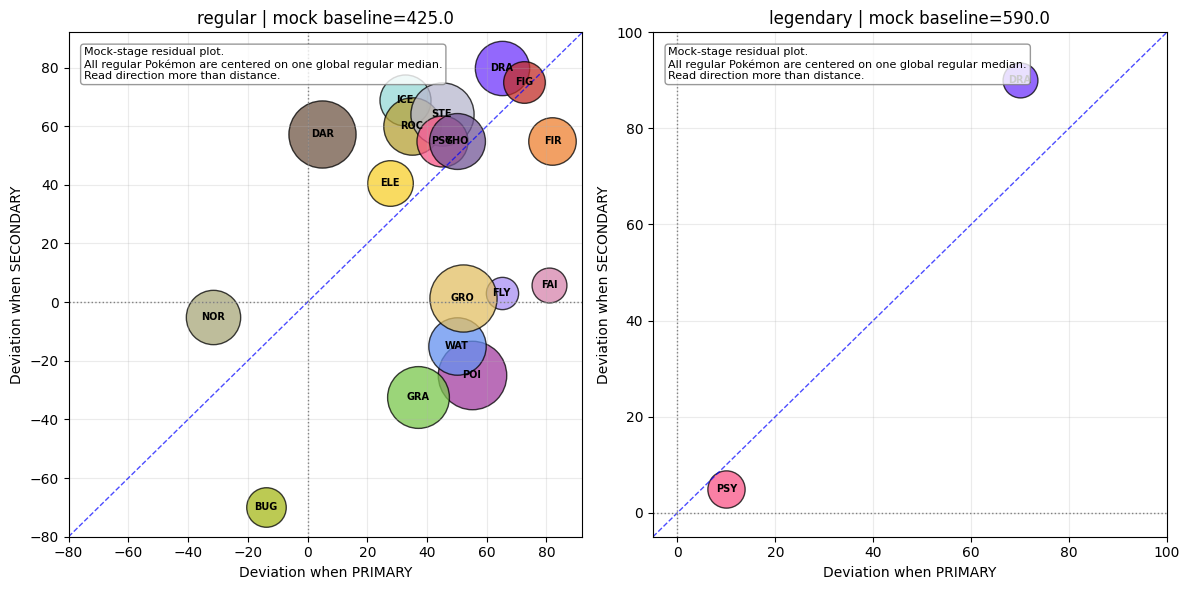

In [6]:
long_df = plot_mock_stage_ordering(df, min_count=5)

In [7]:
build_mock_stage_df(df)

(         rarity      type  mock_stage_deviation    order
 0       regular      fire                -116.0     mono
 1       regular      fire                 -20.0     mono
 2       regular     water                -111.0     mono
 3       regular     water                 -20.0     mono
 4       regular     water                 105.0     mono
 ...         ...       ...                   ...      ...
 1650    regular      rock                  89.0  dual_t2
 1651    regular  fighting                 105.0  dual_t2
 1652  legendary    dragon                  90.0  dual_t2
 1653  legendary    dragon                  90.0  dual_t2
 1654    regular    ground                -215.0  dual_t2
 
 [1655 rows x 4 columns],
 np.float64(425.0),
 np.float64(590.0))

In [8]:
import numpy as np
import pandas as pd

def project_to_mock_stage(df):
    work = df.copy()

    regular_mask = work['rarity'].eq('regular')
    legendary_mask = work['rarity'].eq('legendary')

    # Stage medians for regular Pokémon
    stage_medians = work.loc[regular_mask].groupby('stage')['total_stats'].median()

    # Shared reference stage for regular Pokémon
    reference_regular = work.loc[regular_mask, 'total_stats'].median()

    # Legendary reference can be separate
    reference_legendary = work.loc[legendary_mask, 'total_stats'].median()

    work['stage_median'] = np.nan
    work['bst_projected_mock_stage'] = np.nan

    # Regular: project to the common mock stage
    work.loc[regular_mask, 'stage_median'] = work.loc[regular_mask, 'stage'].map(stage_medians)
    work.loc[regular_mask, 'bst_projected_mock_stage'] = (
        work.loc[regular_mask, 'total_stats']
        - work.loc[regular_mask, 'stage_median']
        + reference_regular
    )

    # Legendary: project to its own common baseline, if you want it included
    work.loc[legendary_mask, 'stage_median'] = reference_legendary
    work.loc[legendary_mask, 'bst_projected_mock_stage'] = (
        work.loc[legendary_mask, 'total_stats']
        - reference_legendary
        + reference_legendary
    )

    return work, stage_medians, reference_regular, reference_legendary

project_to_mock_stage(df)[0]

,generation,name,type_1,type_2,rarity,stage,shape,color,total_stats,height,weight,stage_median,bst_projected_mock_stage
0,1,bulbasaur,grass,poison,regular,s1c3,quadruped,green,318,0.7,6.9,300.0,443.0
1,1,ivysaur,grass,poison,regular,s2c3,quadruped,green,405,1.0,13.0,405.0,425.0
2,1,venusaur,grass,poison,regular,s3c3,quadruped,green,525,2.0,100.0,521.5,428.5
3,1,charmander,fire,NaN,regular,s1c3,upright,red,309,0.6,8.5,300.0,434.0
4,1,charmeleon,fire,NaN,regular,s2c3,upright,red,405,1.1,19.0,405.0,425.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077,9,decidueye_hisui,grass,fighting,regular,s3c3,wings,brown,530,1.6,37.0,521.5,433.5
1078,9,dialga_hisui,steel,dragon,legendary,single,quadruped,white,680,7.0,848.7,590.0,680.0
1079,9,palkia_hisui,water,dragon,legendary,single,upright,purple,680,6.3,659.0,590.0,680.0
1080,9,wooper_paldea,poison,ground,regular,s1c2,legs,blue,210,0.4,11.0,310.0,325.0


In [9]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


TYPE_COLORS = {
    'normal': '#A8A77A',
    'fire': '#EE8130',
    'water': '#6390F0',
    'electric': '#F7D02C',
    'grass': '#7AC74C',
    'ice': '#96D9D6',
    'fighting': '#C22E28',
    'poison': '#A33EA1',
    'ground': '#E2BF65',
    'flying': '#A98FF3',
    'psychic': '#F95587',
    'bug': '#A6B91A',
    'rock': '#B6A136',
    'ghost': '#735797',
    'dragon': '#6F35FC',
    'dark': '#705746',
    'steel': '#B7B7CE',
    'fairy': '#D685AD',
}


# ------------------------------------------------------------
# 1) PROJECT RAW BST TO A COMMON MOCK STAGE
# ------------------------------------------------------------
def project_bst_to_mock_stage(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Project each Pokémon's BST to a common reference stage.

    For regular Pokémon:
        projected_bst = total_stats - stage_median + reference_regular

    For legendary Pokémon:
        projected_bst = total_stats - legendary_median + reference_legendary
    which equals the original total_stats if reference_legendary = legendary_median.

    Returns
    -------
    projected_df : pd.DataFrame
        Original dataframe plus:
        - real_stage_median
        - reference_bst
        - bst_projected_mock_stage
        - projected_deviation
    meta : dict
        Useful baselines and stage medians
    """

    work = df.copy()

    regular_mask = work['rarity'].eq('regular')
    legendary_mask = work['rarity'].eq('legendary')

    regular_stage_medians = (
        work.loc[regular_mask]
        .groupby('stage')['total_stats']
        .median()
    )

    reference_regular = work.loc[regular_mask, 'total_stats'].median()
    reference_legendary = work.loc[legendary_mask, 'total_stats'].median()

    work['real_stage_median'] = np.nan
    work['reference_bst'] = np.nan
    work['bst_projected_mock_stage'] = np.nan
    work['projected_deviation'] = np.nan

    # Regular: move each BST from its real stage median to one common regular baseline
    work.loc[regular_mask, 'real_stage_median'] = (
        work.loc[regular_mask, 'stage'].map(regular_stage_medians)
    )
    work.loc[regular_mask, 'reference_bst'] = reference_regular
    work.loc[regular_mask, 'bst_projected_mock_stage'] = (
        work.loc[regular_mask, 'total_stats']
        - work.loc[regular_mask, 'real_stage_median']
        + reference_regular
    )
    work.loc[regular_mask, 'projected_deviation'] = (
        work.loc[regular_mask, 'bst_projected_mock_stage'] - reference_regular
    )

    # Legendary: keep a separate reference
    work.loc[legendary_mask, 'real_stage_median'] = reference_legendary
    work.loc[legendary_mask, 'reference_bst'] = reference_legendary
    work.loc[legendary_mask, 'bst_projected_mock_stage'] = (
        work.loc[legendary_mask, 'total_stats']
        - reference_legendary
        + reference_legendary
    )
    work.loc[legendary_mask, 'projected_deviation'] = (
        work.loc[legendary_mask, 'bst_projected_mock_stage'] - reference_legendary
    )

    meta = {
        'regular_stage_medians': regular_stage_medians,
        'reference_regular': reference_regular,
        'reference_legendary': reference_legendary,
    }

    return work, meta


# ------------------------------------------------------------
# 2) BUILD LONG TABLE FOR TYPE-ORDER EDA
# ------------------------------------------------------------
def build_type_order_long(projected_df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert type_1/type_2 into long format with explicit order labels.
    """

    mono = (
        projected_df.loc[
            projected_df['type_2'].isna(),
            ['name', 'stage', 'rarity', 'type_1', 'total_stats',
             'bst_projected_mock_stage', 'projected_deviation']
        ]
        .rename(columns={'type_1': 'type'})
        .assign(order='mono')
    )

    dual_t1 = (
        projected_df.loc[
            projected_df['type_2'].notna(),
            ['name', 'stage', 'rarity', 'type_1', 'total_stats',
             'bst_projected_mock_stage', 'projected_deviation']
        ]
        .rename(columns={'type_1': 'type'})
        .assign(order='dual_t1')
    )

    dual_t2 = (
        projected_df.loc[
            projected_df['type_2'].notna(),
            ['name', 'stage', 'rarity', 'type_2', 'total_stats',
             'bst_projected_mock_stage', 'projected_deviation']
        ]
        .rename(columns={'type_2': 'type'})
        .assign(order='dual_t2')
    )

    long_df = pd.concat([mono, dual_t1, dual_t2], ignore_index=True)
    return long_df


# ------------------------------------------------------------
# 3) COMPARE PRIMARY VS SECONDARY ORDERING
# ------------------------------------------------------------
def compare_projected_type_order(long_df: pd.DataFrame,
                                 rarity: str = 'regular',
                                 stage: str | None = None,
                                 min_count: int = 3,
                                 aggregate_stages: bool = True) -> pd.DataFrame:
    """
    Build comparison table for projected deviations.

    If aggregate_stages=True:
        all rows of the chosen rarity are pooled together.

    If aggregate_stages=False and stage is provided:
        filter to one stage only.
    """

    subset = long_df[long_df['rarity'].eq(rarity)].copy()

    if not aggregate_stages and stage is not None:
        subset = subset[subset['stage'].eq(stage)].copy()

    subset = subset[subset['order'].isin(['dual_t1', 'dual_t2'])].copy()

    if subset.empty:
        return pd.DataFrame()

    pivot_dev = subset.pivot_table(
        index='type',
        columns='order',
        values='projected_deviation',
        aggfunc='median'
    )

    pivot_count = subset.pivot_table(
        index='type',
        columns='order',
        values='total_stats',
        aggfunc='size'
    ).fillna(0).astype(int)

    if not {'dual_t1', 'dual_t2'}.issubset(pivot_dev.columns):
        return pd.DataFrame()
    if not {'dual_t1', 'dual_t2'}.issubset(pivot_count.columns):
        return pd.DataFrame()

    comparison = pd.DataFrame({
        'type': pivot_dev.index,
        'dual_t1_dev': pivot_dev['dual_t1'],
        'dual_t2_dev': pivot_dev['dual_t2'],
        'n_t1': pivot_count['dual_t1'],
        'n_t2': pivot_count['dual_t2'],
    }).reset_index(drop=True)

    comparison['paired_n'] = comparison[['n_t1', 'n_t2']].min(axis=1)
    comparison = comparison[comparison['paired_n'] >= min_count].copy()

    if comparison.empty:
        return comparison

    comparison['difference'] = comparison['dual_t1_dev'] - comparison['dual_t2_dev']
    comparison['abs_diff'] = comparison['difference'].abs()
    comparison['direction'] = np.where(
        comparison['difference'] > 0, 'primary_higher',
        np.where(comparison['difference'] < 0, 'secondary_higher', 'tie')
    )

    return comparison.sort_values('abs_diff', ascending=False)


# ------------------------------------------------------------
# 4) PLOT THE PROJECTED SCATTER
# ------------------------------------------------------------
def plot_projected_type_order(comparison_regular: pd.DataFrame,
                              comparison_legendary: pd.DataFrame,
                              meta: dict,
                              plot_path: str = 'plots/eda/projected_type_ordering.png'):
    """
    Plot projected type-order scatter for regular and legendary.
    """

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    panels = [
        ('regular', comparison_regular, meta['reference_regular']),
        ('legendary', comparison_legendary, meta['reference_legendary']),
    ]

    for ax, (rarity, comp, ref) in zip(axes, panels):
        if comp.empty:
            ax.set_title(f'{rarity} | no data')
            ax.axis('off')
            continue

        for _, row in comp.iterrows():
            t = str(row['type']).lower()
            x = row['dual_t1_dev']
            y = row['dual_t2_dev']
            size = row['paired_n'] * 10

            ax.scatter(
                x, y,
                s=size,
                color=TYPE_COLORS.get(t, 'gray'),
                edgecolor='black',
                linewidth=1,
                alpha=0.75
            )

            ax.text(
                x, y, str(row['type'])[:3].upper(),
                fontsize=6, ha='right', va='baseline',
                fontweight='bold'
            )

        low = min(comp['dual_t1_dev'].min(), comp['dual_t2_dev'].min()) - 15
        high = max(comp['dual_t1_dev'].max(), comp['dual_t2_dev'].max()) + 15

        ax.plot([low, high], [low, high], 'b--', alpha=0.7, linewidth=1)
        ax.axhline(0, color='gray', linestyle=':', linewidth=1)
        ax.axvline(0, color='gray', linestyle=':', linewidth=1)

        ax.set_xlim(low, high)
        ax.set_ylim(low, high)
        ax.grid(alpha=0.25)

        ax.set_xlabel('Deviation when PRIMARY')
        ax.set_ylabel('Deviation when SECONDARY')
        ax.set_title(f'{rarity} | mock baseline={ref:.1f}')

        ax.text(
            0.03, 0.97,
            'Projected-to-mock-stage plot\nRead direction more than distance',
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        )

    Path(plot_path).parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=400, bbox_inches='tight')
    plt.show()


# ------------------------------------------------------------
# 5) STAGE-WISE DIRECTION CHECK
# ------------------------------------------------------------
def stage_direction_summary(long_df: pd.DataFrame,
                            rarity: str = 'regular',
                            min_count: int = 3) -> pd.DataFrame:
    """
    Check direction consistency by stage.
    """

    rows = []
    if rarity == 'legendary':
        return pd.DataFrame()

    for stage in sorted(long_df.loc[long_df['rarity'].eq('regular'), 'stage'].dropna().unique()):
        comp = compare_projected_type_order(
            long_df=long_df,
            rarity='regular',
            stage=stage,
            min_count=min_count,
            aggregate_stages=False
        )

        if comp.empty:
            rows.append({
                'stage': stage,
                'n_points': 0,
                'median_abs_diff': np.nan,
                'share_primary_higher': np.nan,
                'share_secondary_higher': np.nan,
                'dominant_direction': 'no_data',
            })
            continue

        primary_share = (comp['difference'] > 0).mean()
        secondary_share = (comp['difference'] < 0).mean()

        if primary_share > 0.6:
            dom = 'primary_higher'
        elif secondary_share > 0.6:
            dom = 'secondary_higher'
        else:
            dom = 'mixed'

        rows.append({
            'stage': stage,
            'n_points': len(comp),
            'median_abs_diff': comp['abs_diff'].median(),
            'share_primary_higher': primary_share,
            'share_secondary_higher': secondary_share,
            'dominant_direction': dom,
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 6) PASS/FAIL EVALUATION
# ------------------------------------------------------------
def evaluate_projected_signal(long_df: pd.DataFrame,
                              comparison_regular: pd.DataFrame,
                              comparison_legendary: pd.DataFrame,
                              min_count: int = 3,
                              dominant_share_threshold: float = 0.6,
                              min_regular_points: int = 6,
                              min_repeating_stages: int = 2) -> tuple[pd.DataFrame, dict]:
    """
    Evaluate strict EDA pass criteria.

    Criteria:
    1. Regular panel has enough points.
    2. Signal is not legend-only.
    3. At least 2 stages show the same dominant direction.
    4. Signal is not driven by only one or two extreme types.
    5. Typical effect size is non-trivial.
    """

    summary_stage = stage_direction_summary(long_df, rarity='regular', min_count=min_count)

    if comparison_regular.empty:
        summary = pd.DataFrame([{
            'criterion': 'Regular projected signal exists',
            'passed': False,
            'detail': 'No regular comparison points available'
        }])
        return summary, {'stage_summary': summary_stage}

    # 1. Enough points in regular comparison
    c1 = len(comparison_regular) >= min_regular_points

    # 2. Signal not legend-only
    c2 = len(comparison_regular) > 0

    # 3. Repeated direction across stages
    stage_nonempty = summary_stage[summary_stage['dominant_direction'].isin(['primary_higher', 'secondary_higher'])]
    direction_counts = stage_nonempty['dominant_direction'].value_counts()
    max_repeat = direction_counts.max() if not direction_counts.empty else 0
    c3 = max_repeat >= min_repeating_stages

    # 4. Not dominated by one extreme type
    top2 = comparison_regular['abs_diff'].nlargest(min(2, len(comparison_regular))).sum()
    total_abs = comparison_regular['abs_diff'].sum()
    top2_share = top2 / total_abs if total_abs > 0 else 1.0
    c4 = top2_share < 0.70

    # 5. Non-trivial median effect
    median_abs = comparison_regular['abs_diff'].median()
    c5 = median_abs >= 10

    # Optional descriptive checks
    median_paired_n = comparison_regular['paired_n'].median()
    legend_has_support = not comparison_legendary.empty

    summary = pd.DataFrame([
        {
            'criterion': 'Enough regular points',
            'passed': c1,
            'detail': f'n_regular_points={len(comparison_regular)}, threshold={min_regular_points}'
        },
        {
            'criterion': 'Not legend-only',
            'passed': c2,
            'detail': f'regular_points={len(comparison_regular)}, legendary_points={len(comparison_legendary)}'
        },
        {
            'criterion': 'Repeated stage direction',
            'passed': c3,
            'detail': f'max repeating stage direction count={max_repeat}, threshold={min_repeating_stages}'
        },
        {
            'criterion': 'Not dominated by top 2 types',
            'passed': c4,
            'detail': f'top2 abs-diff share={top2_share:.2f}, threshold<0.70'
        },
        {
            'criterion': 'Median effect is non-trivial',
            'passed': c5,
            'detail': f'median abs diff={median_abs:.1f}, threshold>=10'
        },
        {
            'criterion': 'Descriptive support only',
            'passed': True,
            'detail': f'median paired n={median_paired_n:.1f}, legendary_has_points={legend_has_support}'
        },
    ])

    extras = {
        'stage_summary': summary_stage,
        'top_regular_types': comparison_regular[['type', 'difference', 'abs_diff', 'paired_n']].head(10),
    }

    return summary, extras


# ------------------------------------------------------------
# 7) ONE-STOP RUNNER
# ------------------------------------------------------------
def run_projected_type_order_eda(df: pd.DataFrame,
                                 min_count: int = 3,
                                 plot_path: str = 'plots/eda/projected_type_ordering.png'):
    """
    Full workflow:
    - project BST to mock stage
    - build long table
    - compare type order for regular and legendary
    - plot
    - evaluate pass criteria
    """

    projected_df, meta = project_bst_to_mock_stage(df)
    long_df = build_type_order_long(projected_df)

    comparison_regular = compare_projected_type_order(
        long_df=long_df,
        rarity='regular',
        min_count=min_count,
        aggregate_stages=True
    )

    comparison_legendary = compare_projected_type_order(
        long_df=long_df,
        rarity='legendary',
        min_count=min_count,
        aggregate_stages=True
    )

    plot_projected_type_order(
        comparison_regular=comparison_regular,
        comparison_legendary=comparison_legendary,
        meta=meta,
        plot_path=plot_path
    )

    checklist, extras = evaluate_projected_signal(
        long_df=long_df,
        comparison_regular=comparison_regular,
        comparison_legendary=comparison_legendary,
        min_count=min_count
    )

    return {
        'projected_df': projected_df,
        'long_df': long_df,
        'comparison_regular': comparison_regular,
        'comparison_legendary': comparison_legendary,
        'checklist': checklist,
        'stage_summary': extras['stage_summary'],
        'top_regular_types': extras['top_regular_types'],
        'meta': meta,
    }

In [10]:
def make_projected_signal_verdict(checklist: pd.DataFrame,
                                  stage_summary: pd.DataFrame,
                                  comparison_regular: pd.DataFrame,
                                  comparison_legendary: pd.DataFrame) -> dict:
    """
    Convert checklist + summaries into an automatic verdict.

    Returns
    -------
    dict with:
    - verdict
    - score
    - passed_count
    - total_criteria
    - rationale
    """

    scored_checks = checklist[checklist['criterion'] != 'Descriptive support only'].copy()
    passed_count = int(scored_checks['passed'].sum())
    total_criteria = len(scored_checks)
    score = passed_count / total_criteria if total_criteria else 0.0

    regular_points = len(comparison_regular)
    legendary_points = len(comparison_legendary)

    if stage_summary is not None and not stage_summary.empty:
        dominant = stage_summary['dominant_direction'].value_counts()
        repeated_direction = dominant.max() if not dominant.empty else 0
    else:
        repeated_direction = 0

    median_abs_diff = float(comparison_regular['abs_diff'].median()) if regular_points else 0.0
    median_paired_n = float(comparison_regular['paired_n'].median()) if regular_points else 0.0

    rationale = []

    if score >= 0.80 and regular_points >= 8 and repeated_direction >= 2:
        verdict = 'strong candidate for feature engineering'
        rationale.append('Most strict checks passed.')
        rationale.append('Regular signal has enough visible support.')
        rationale.append('Direction repeats across stages.')
    elif score >= 0.60 and regular_points >= 5:
        verdict = 'keep as weak secondary candidate'
        rationale.append('Signal is present but not fully stable.')
        rationale.append('Use only as a low-priority engineered feature.')
        rationale.append('Model should be allowed to downweight it.')
    else:
        verdict = 'reject for now'
        rationale.append('Signal is too weak or too unstable.')
        rationale.append('Keep as an EDA observation only.')
        rationale.append('Do not promote to feature engineering yet.')

    # Extra nuance
    if median_paired_n < 5:
        rationale.append('Typical paired subgroup support is very small.')
    if median_abs_diff < 10:
        rationale.append('Typical effect size is modest after projection.')
    if legendary_points > 0 and regular_points == 0:
        rationale.append('Pattern appears legend-only, which is too narrow.')
    elif legendary_points > 0:
        rationale.append('Legendary panel can be used only as a secondary confirmation, not as main evidence.')

    return {
        'verdict': verdict,
        'score': score,
        'passed_count': passed_count,
        'total_criteria': total_criteria,
        'rationale': rationale,
    }

In [11]:
def print_projected_signal_verdict(verdict_info: dict):
    """
    Pretty-print the automatic verdict.
    """

    print('\n' + '=' * 70)
    print('PROJECTED TYPE-ORDER SIGNAL VERDICT')
    print('=' * 70)
    print(f"Verdict      : {verdict_info['verdict']}")
    print(f"Score        : {verdict_info['score']} "
          f"({verdict_info['passed_count']}/{verdict_info['total_criteria']} strict checks passed)")
    print('Rationale    :')
    for line in verdict_info['rationale']:
        print(f"  - {line}")
    print('=' * 70 + '\n')

In [12]:
def run_projected_type_order_eda(df: pd.DataFrame,
                                 min_count: int = 3,
                                 plot_path: str = 'plots/eda/projected_type_ordering.png'):
    projected_df, meta = project_bst_to_mock_stage(df)
    long_df = build_type_order_long(projected_df)

    comparison_regular = compare_projected_type_order(
        long_df=long_df,
        rarity='regular',
        min_count=min_count,
        aggregate_stages=True
    )

    comparison_legendary = compare_projected_type_order(
        long_df=long_df,
        rarity='legendary',
        min_count=min_count,
        aggregate_stages=True
    )

    plot_projected_type_order(
        comparison_regular=comparison_regular,
        comparison_legendary=comparison_legendary,
        meta=meta,
        plot_path=plot_path
    )

    checklist, extras = evaluate_projected_signal(
        long_df=long_df,
        comparison_regular=comparison_regular,
        comparison_legendary=comparison_legendary,
        min_count=min_count
    )

    verdict_info = make_projected_signal_verdict(
        checklist=checklist,
        stage_summary=extras['stage_summary'],
        comparison_regular=comparison_regular,
        comparison_legendary=comparison_legendary
    )

    print_projected_signal_verdict(verdict_info)

    return {
        'projected_df': projected_df,
        'long_df': long_df,
        'comparison_regular': comparison_regular,
        'comparison_legendary': comparison_legendary,
        'checklist': checklist,
        'stage_summary': extras['stage_summary'],
        'top_regular_types': extras['top_regular_types'],
        'verdict': verdict_info,
        'meta': meta,
    }

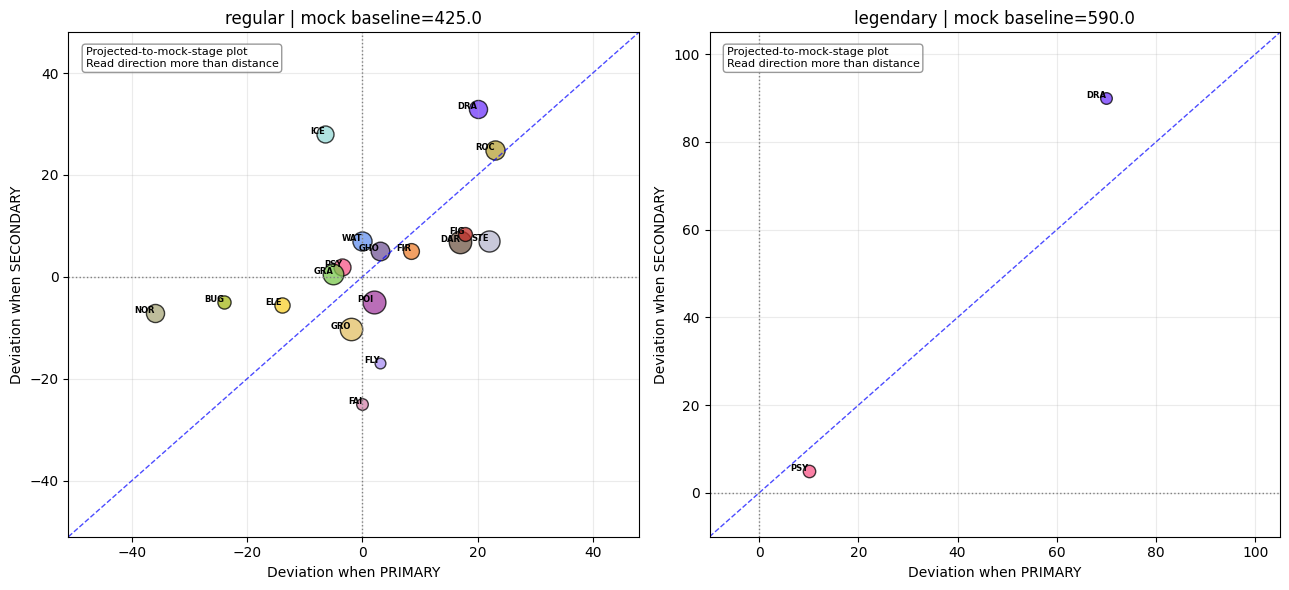


PROJECTED TYPE-ORDER SIGNAL VERDICT
Verdict      : keep as weak secondary candidate
Score        : 0.6 (3/5 strict checks passed)
Rationale    :
  - Signal is present but not fully stable.
  - Use only as a low-priority engineered feature.
  - Model should be allowed to downweight it.
  - Typical effect size is modest after projection.
  - Legendary panel can be used only as a secondary confirmation, not as main evidence.



,type,difference,abs_diff,paired_n
11,ice,-34.50,34.50,15
12,normal,-29.00,29.00,17
4,fairy,25.00,25.00,7
7,flying,20.00,20.00,6
0,bug,-19.00,19.00,9
16,steel,15.00,15.00,23
2,dragon,-13.00,13.00,17
1,dark,10.25,10.25,26
5,fighting,9.25,9.25,10
3,electric,-8.50,8.50,12


In [13]:
results = run_projected_type_order_eda(df, min_count=5)

results['verdict']
results['checklist']
results['stage_summary']
results['top_regular_types']